## Стохастический градиентный спуск

In [1]:
import numpy as np
import pandas as pd
from math import sqrt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
import matplotlib.pyplot as plt

#### Построение графиков

In [2]:
def evaluate_model_visual(model_name, y_pred, y_test):
    plt.figure(figsize=(10, 6))
    
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, edgecolor='w')
    
    line_coords = [y_test.min(), y_test.max()]
    plt.plot(line_coords, line_coords, color='blue', linestyle='--', lw=2, label='Идеальные предсказания')
    
    plt.title(f'Анализ модели {model_name}')
    plt.xlabel('Реальные цены (Actual)')
    plt.ylabel('Предсказанные цены (Predicted)')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.show()

#### Чтение данных

In [3]:
data = pd.read_csv(f'../data/diamonds_filtered.csv')

data.head()

,carat,cut,color,clarity,depth,table,price,radius
0,0.29,4,2,4,62.4,58,334,2.100
1,0.31,2,1,2,63.3,58,335,2.170
2,0.30,2,1,3,64.0,55,339,2.125
3,0.31,5,1,2,62.2,54,344,2.175
4,0.32,4,6,1,60.9,58,345,2.190


#### Выделение целевого признака и предиктора

In [4]:
y = data['price']
x = data.drop(['price'], axis=1)

#### Разделение данных на обучающую и тестовую выборки

In [5]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.15, random_state=81)

#### Масштабирование данных

Стандартизация данных необходима для приведения признаков с разными диапазонами значений (например, караты и цена) к единому масштабу. Это предотвращает доминирование крупных числовых значений над мелкими и обеспечивает стабильную и быструю сходимость алгоритма градиентного спуска

In [6]:
scaler_x = StandardScaler()
scaler_y = StandardScaler()

x_train_scaled = scaler_x.fit_transform(x_train)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1)).flatten()
x_test_scaled = scaler_x.transform(x_test)

- `fit_transform` используется для одновременного вычисления параметров распределения (среднего и отклонения) и приведения данных к стандартному виду.

- При обработке `y_train` мы превращаем `Series` в вертикальную матрицу с n строками, так как `StandardScaler` требует строк и столбцов. Далее, переводим матрицу в одномерный массив при помощи `flatten`, чтобы в дальнейшем было удобно считать метрики.

#### Построение стохастического градиентного спуска

In [7]:
def gradient_descent(x_train, y_train, x_test, y_test):
    alpha = 0.001
    reg = 0.01
    iters = 100
    n_samples = x_train.shape[0]
    n_features = x_train.shape[1] 
    results = []

    m = np.zeros(n_features)
    b = 0
    

    for iter in range(iters):
        for i in range(n_samples):
            x_i = x_train[i]
            y_i = y_train[i]

            y_pred_i = np.dot(x_i, m) + b

            dm = (-2) * x_i * (y_i - y_pred_i) + 2 * reg * m       # штраф на большие веса m
            db = (-2) * (y_i - y_pred_i)        # смещение не штрафуют, тк b двигает линию только вверх или вниз, не влияя на переобучение

            m = m - alpha * dm
            b = b - alpha * db

    y_pred_scaled = np.dot(x_test, m) + b
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    
    metrics = {
        'Model': 'SGD Regressor',
        'MAE':  round(mean_absolute_error(y_test, y_pred), 4),
        'MSE':  round(mean_squared_error(y_test, y_pred), 4),
        'RMSE': round(sqrt(mean_squared_error(y_test, y_pred)), 4),
        'MAPE': round(mean_absolute_percentage_error(y_test, y_pred), 4),
        'R2':   round(r2_score(y_test, y_pred), 5)
    }

    results.append(metrics)

    return results, y_pred

- `inverse_transform` выполняет дестандартизацию предсказанных значений, переводя их обратно в исходный масштаб цен (доллары). Это необходимо для интерпретации результатов и корректного вычисления метрик ошибки (`MAE`, `RMSE`) в реальных денежных единицах

#### Обучение кастомной модели

In [8]:
results, y_pred = gradient_descent(x_train_scaled, y_train_scaled, x_test_scaled, y_test)

#### Метрики

In [9]:
results_df = pd.DataFrame(results)
results_df

,Model,MAE,MSE,RMSE,MAPE,R2
0,SGD Regressor,743.8317,1.194961e+06,1093.1428,0.3905,0.90469


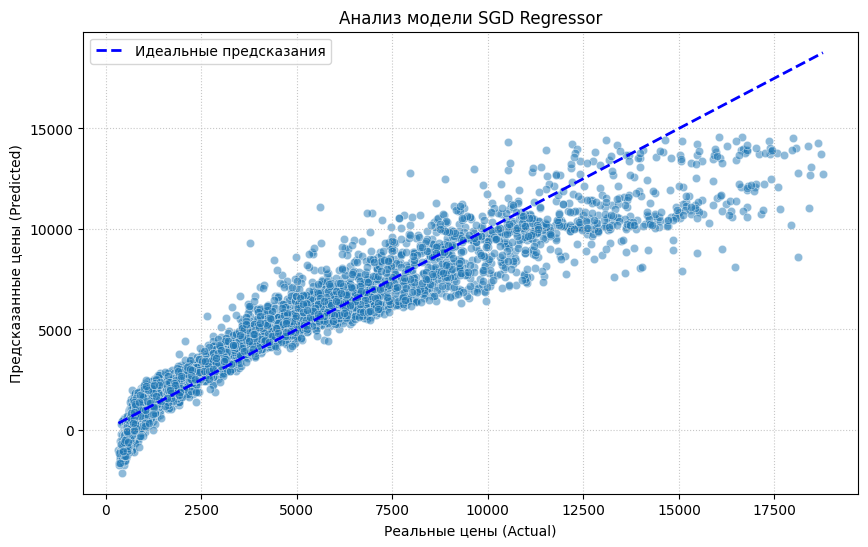

In [10]:
evaluate_model_visual("SGD Regressor", y_pred, y_test)

### Вывод
- Полиномиальная регрессия четвертной степени показала самые высокие метрики, а также ее точность можно оценить на графике. 
- Метрики регуляризаций L1, L2 после подбора гиперпараметров при помощи `GridSearchCV` и `RandomizedSearchCV` остались не изменными, что говорит о высокой изначальной точности алгоритмов.
- Однако метрики `ElasticNet` довольно серьезно улучшились при помощи фреймворка `Optuna`: R^2 = 0.85 -> R^2 = 0.91